In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from wordcloud import WordCloud

# Mount Google Drive
drive.mount('/content/drive')

# Define file path as requested
file_path = '/content/drive/MyDrive/Colab Notebooks/OIBSIPDataAnalytics-L1-EDARetailSales/IMDB Dataset.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load dataset
df = pd.read_csv(file_path)

# Inspect distribution
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# Optional: To speed up execution in Colab while retaining representation, take a sample
# Remove or comment the line below if you want to run on the full 50,000 dataset rows
df_sample = df.sample(n=10000, random_state=42).reset_index(drop=True)
print("\nSample Class Distribution:")
print(df_sample['sentiment'].value_counts())

Dataset Shape: (50000, 2)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Class Distribution:
sentiment
positive    5039
negative    4961
Name: count, dtype: int64


In [3]:
def preprocess_text(text):
    # 1. Remove HTML break tags commonly found in web scraped movie reviews
    text = re.sub(r'<br\s*/?>', ' ', text)
    # 2. Convert text to lowercase
    text = text.lower()
    # 3. Remove punctuation characters
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Tokenize by splitting whitespace and filter out English stop words
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

# Apply the preprocessing pipeline to the dataset
df_sample['clean_review'] = df_sample['review'].apply(preprocess_text)
print("Original Review Snippet:\n", df_sample['review'].iloc[0][:200])
print("\nCleaned Review Snippet:\n", df_sample['clean_review'].iloc[0][:200])

Original Review Snippet:
 I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev

Cleaned Review Snippet:
 really liked summerslam look arena curtains just look overall interesting reason anyways best summerslams wwf didnt lex luger main event yokozuna time ok huge fat man vs strong man im glad times chang


In [4]:
#What is TF-IDF?
#TF-IDF stands for Term Frequency-Inverse Document Frequency. It is a numerical statistic
intended to reflect how important a word is to a document in a collection or corpus.

#1.Term Frequency ($\text{TF}$): Measures how frequently a term occurs in a document.
#$$\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}$$

#2.Inverse Document Frequency ($\text{IDF}$):
#Measures how important a term is across the entire corpus. It down-weights words that appear very frequently everywhere (like "movie", "film", "show") and highlights rare, informative words.
#$$\text{IDF}(t, D) = \log\left(\frac{\text{Total number of documents } D}{\text{Number of documents containing term } t}\right)$$
#The final TF-IDF weight is obtained by multiplying these two values: $\text{TF-IDF} = \text{TF} \times \text{IDF}$. This turns raw unstructured text strings into a sparse matrix of continuous numerical features suitable for machine learning algorithms.


In [5]:
# Map target labels to numerical values
X = df_sample['clean_review']
y = df_sample['sentiment'].map({'positive': 1, 'negative': 0})

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df_sample.index, test_size=0.20, random_state=42
)

# Extract TF-IDF Features limiting to top 5000 terms
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Testing feature matrix shape: {X_test_tfidf.shape}")

Training feature matrix shape: (8000, 5000)
Testing feature matrix shape: (2000, 5000)


In [6]:
# Initialize Classifiers
nb_model = MultinomialNB()
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train Classifiers
nb_model.fit(X_train_tfidf, y_train)
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_tfidf)
y_pred_lr = lr_model.predict(X_test_tfidf)

# Helper Evaluation Function
def evaluate_model(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n==================== {name} ====================")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
    return cm

cm_nb = evaluate_model(y_test, y_pred_nb, "Multinomial Naive Bayes")
cm_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression")


==================== Multinomial Naive Bayes ====================
Accuracy:  0.8515
Precision: 0.8541
Recall:    0.8482
F1-Score:  0.8511

Classification Report:
               precision    recall  f1-score   support

    Negative       0.85      0.85      0.85       999
    Positive       0.85      0.85      0.85      1001

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


==================== Logistic Regression ====================
Accuracy:  0.8735
Precision: 0.8569
Recall:    0.8971
F1-Score:  0.8765

Classification Report:
               precision    recall  f1-score   support

    Negative       0.89      0.85      0.87       999
    Positive       0.86      0.90      0.88      1001

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



/tmp/ipykernel_479/2543052399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df_sample, palette='viridis', order=['positive', 'negative'])


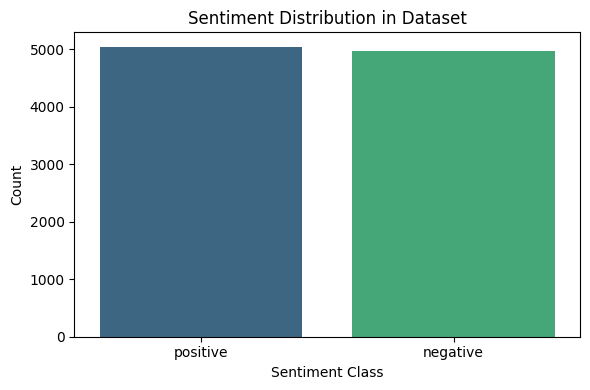

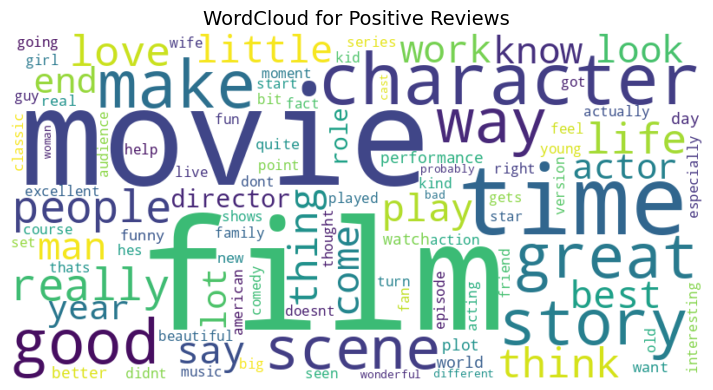

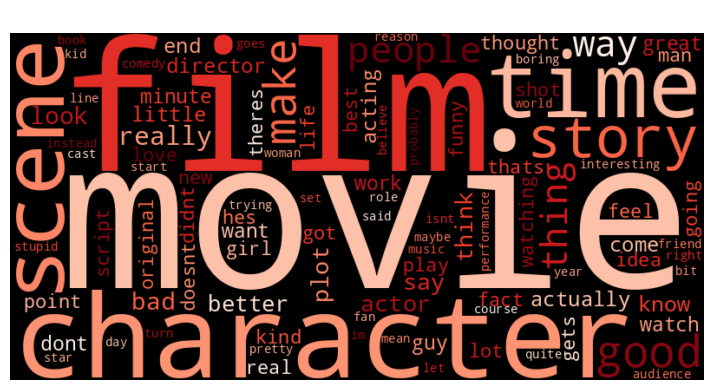

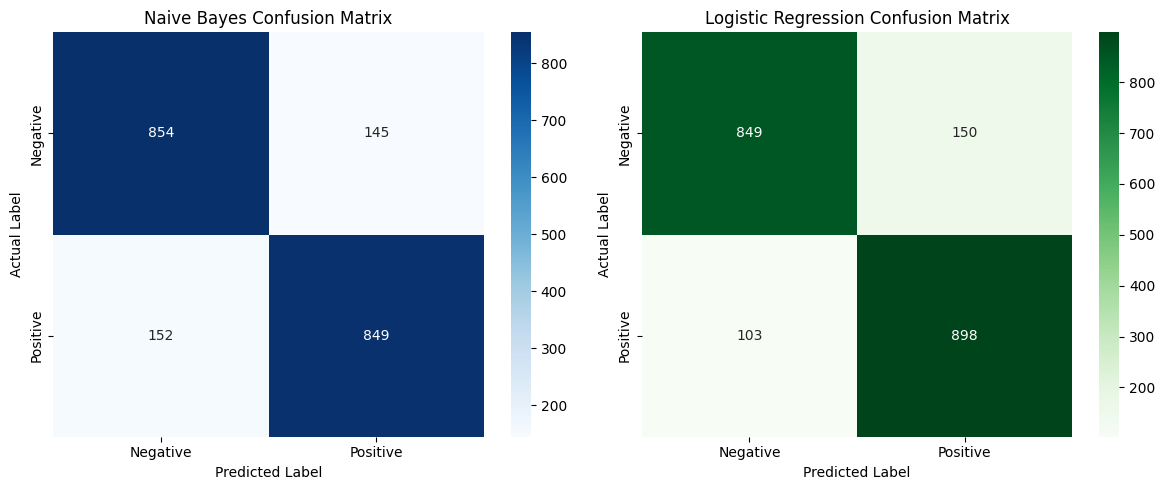

In [7]:
# 1. Bar Chart of Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df_sample, palette='viridis', order=['positive', 'negative'])
plt.title('Sentiment Distribution in Dataset')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

# 2. WordClouds
pos_text = ' '.join(df_sample[df_sample['sentiment'] == 'positive']['clean_review'])
neg_text = ' '.join(df_sample[df_sample['sentiment'] == 'negative']['clean_review'])

# Positive WordCloud
wc_pos = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(pos_text)
plt.figure(figsize=(8, 4))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud for Positive Reviews', fontsize=14)
plt.tight_layout()
plt.savefig('wordcloud_positive.png')
plt.show()

# Negative WordCloud
wc_neg = WordCloud(width=800, height=400, background_color='black', max_words=100, colormap='Reds').generate(neg_text)
plt.figure(figsize=(8, 4))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud for Negative Reviews', fontsize=14, color='white')
plt.tight_layout()
plt.savefig('wordcloud_negative.png')
plt.show()

# 3. Confusion Matrices Heatmap
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=ax[0])
ax[0].set_title('Naive Bayes Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('Actual Label')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=ax[1])
ax[1].set_title('Logistic Regression Confusion Matrix')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('Actual Label')
plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

In [8]:
# Error Analysis on Logistic Regression
test_df = df_sample.iloc[indices_test].copy()
test_df['actual'] = y_test
test_df['predicted'] = y_pred_lr

misclassified = test_df[test_df['actual'] != test_df['predicted']].head(5)
print("--- 5 Misclassified Examples from Logistic Regression ---\n")
for idx, row in misclassified.iterrows():
    act_str = 'positive' if row['actual'] == 1 else 'negative'
    pred_str = 'positive' if row['predicted'] == 1 else 'negative'
    print(f"Index: {idx} | Actual: {act_str.upper()} | Predicted: {pred_str.upper()}")
    print(f"Review Snippet: {row['review'][:350]}...")
    print("-" * 80)

--- 5 Misclassified Examples from Logistic Regression ---

Index: 4742 | Actual: NEGATIVE | Predicted: POSITIVE
Review Snippet: Yes, the votes are in. This film may very well be the Plan 9 From Outer Space for our generation. But whereas Ed Wood's film, for all its flaws, retains a certain charm despite it all, this film defines the word "charmless" to the nth degree. In fact, I'd suggest to the editors of the Oxford English Dictionary to cite this movie as a key example de...
--------------------------------------------------------------------------------
Index: 576 | Actual: NEGATIVE | Predicted: POSITIVE
Review Snippet: I saw this movie when i was much younger and i thought it was funny. I saw it again last week, and you can guess the result. Some funny parts in it, very few and too long. The beginning is the only thing that is funny if you ask me.<br /><br />If you want a total b-movie this is a good pick, but don't expect too much from aliens dwarf size...
------------------------